#Hand Gesture Recognition using Principal Component Analysis (PCA)
### Linear Algebra Project

**Topic:** Applying eigendecomposition and dimensionality reduction to classify hand gestures  
(✊ Rock, 🖐 Paper, ✌ Scissors) from grayscale images — using only core linear algebra, no ML libraries.

---

## Linear Algebra Concepts Used

| Concept | Role in this project |
|---|---|
| **Mean Centering** | Shifts data cloud to the origin |
| **Covariance Matrix** | Captures variance across all 4096 pixel dimensions |
| **Eigendecomposition** | Finds principal directions of maximum variance |
| **Dimensionality Reduction** | Projects 4096-D images → 20-D PCA space |
| **Euclidean Distance** | Nearest-neighbor classification in PCA space |

---

## How to Use This Notebook
1. Run **Section 1** — uploads your dataset ZIP directly into Colab
2. Run **Sections 2–4** — loads images, runs PCA, trains the classifier
3. Run **Section 5** — upload any hand gesture image to get a prediction

In [5]:
from google.colab import files
import zipfile
import os

# Upload dataset zip
uploaded = files.upload()

# Extract zip
for file in uploaded.keys():
    if file.endswith(".zip"):
        with zipfile.ZipFile(file, 'r') as zip_ref:
            zip_ref.extractall("/content/dataset")

# Set dataset path
data_path = "/content/dataset"
gestures = ["rock", "paper", "scissors"]

Saving dataset.zip to dataset (1).zip


In [6]:
import cv2
import numpy as np

data_path = "/content/dataset/dataset" # Corrected path after extraction

images = []
labels = []

for label, gesture in enumerate(gestures):
    folder = os.path.join(data_path, gesture)

    for file in os.listdir(folder):
        img_path = os.path.join(folder, file)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (64, 64))

        images.append(img.flatten())
        labels.append(label)

images = np.array(images)
labels = np.array(labels)

In [7]:
mean = np.mean(images, axis=0)
A_centered = images - mean

cov_matrix = np.cov(A_centered, rowvar=False)

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

idx = np.argsort(eigenvalues)[::-1]
eigenvectors = eigenvectors[:, idx]

# Select top k components
k = 20
Vk = eigenvectors[:, :k]

In [8]:
def recognize(test_img):
    test_img = cv2.resize(test_img, (64, 64))
    test_vec = test_img.flatten().astype(float)

    test_centered = test_vec - mean
    test_proj = test_centered @ Vk

    projections = A_centered @ Vk

    distances = np.linalg.norm(projections - test_proj, axis=1)
    nearest = np.argmin(distances)

    return gestures[labels[nearest]]

Saving p1.png to p1.png
Saving p2.png to p2.png
Saving r1.png to r1.png
Saving r2.png to r2.png
Saving s1.png to s1.png
Saving s2.png to s2.png
Predicted Gesture: paper


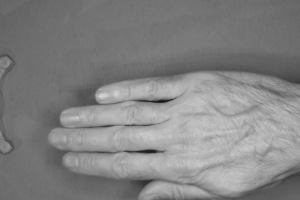

Predicted Gesture: paper


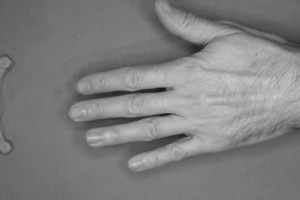

Predicted Gesture: rock


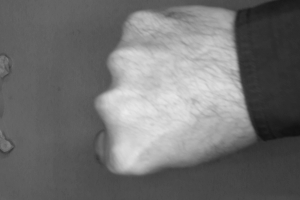

Predicted Gesture: rock


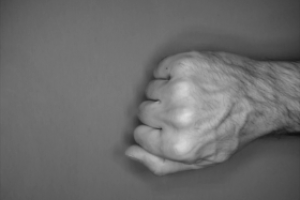

Predicted Gesture: rock


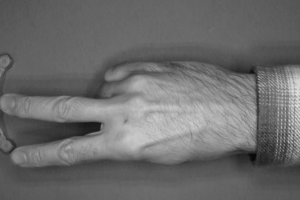

Predicted Gesture: scissors


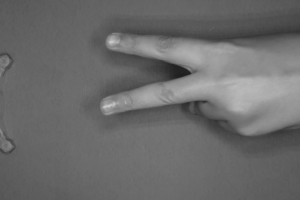

In [9]:
from google.colab import files
from google.colab.patches import cv2_imshow

uploaded = files.upload()

for file in uploaded.keys():
    img = cv2.imread(file, cv2.IMREAD_GRAYSCALE)

    result = recognize(img)

    print("Predicted Gesture:", result)
    cv2_imshow(img)